In [6]:
!pip install pycryptodome


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from Crypto.Cipher import DES
from Crypto.Util.Padding import pad, unpad
import os

In [19]:
# DES key must be exactly 8 bytes
key = b'8bytekey'

input_image = "img1.png"
encrypted_file = "encrypted.des"
decrypted_image = "decrypted.png"

In [27]:
def encrypt_image(input_path, output_path, key):
    cipher = DES.new(key, DES.MODE_CBC)

    with open(input_path, 'rb') as f:
        data = f.read()

    padded_data = pad(data, DES.block_size)
    encrypted_data = cipher.encrypt(padded_data)

    with open(output_path, 'wb') as f:
        f.write(cipher.iv)  # Save IV
        f.write(encrypted_data)

    print("Image Encrypted Successfully!")

In [24]:
def decrypt_image(input_path, output_path, key):
    with open(input_path, 'rb') as f:
        iv = f.read(8)
        encrypted_data = f.read()

    cipher = DES.new(key, DES.MODE_CBC, iv=iv)
    decrypted_data = unpad(cipher.decrypt(encrypted_data), DES.block_size)

    with open(output_path, 'wb') as f:
        f.write(decrypted_data)

    print(" Image Decrypted Successfully!")

In [26]:
encrypt_image(input_image, encrypted_file, key)
decrypt_image(encrypted_file, decrypted_image, key)

✅ Image Encrypted Successfully!
 Image Decrypted Successfully!


Original Image:


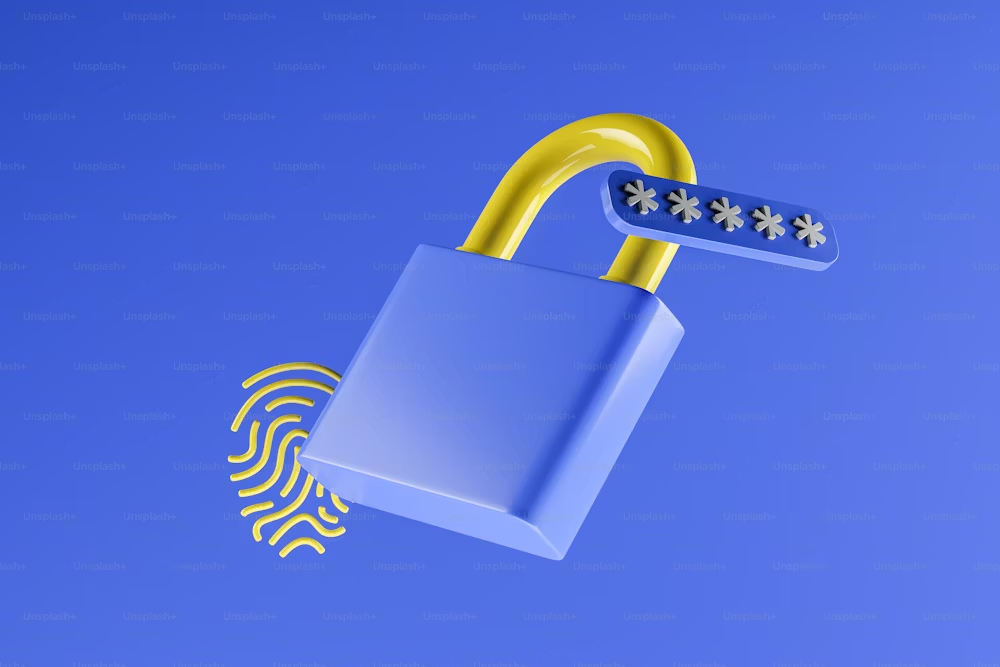


Decrypted Image:


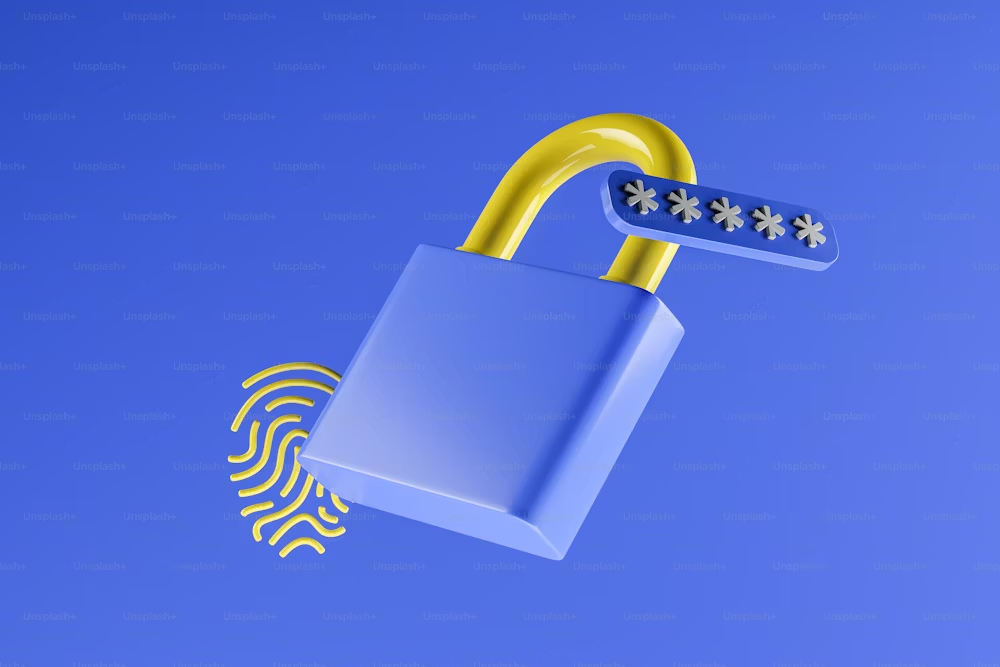

In [23]:
from IPython.display import Image, display

print("Original Image:")
display(Image(filename=input_image))

print("\nDecrypted Image:")
display(Image(filename=decrypted_image))